# Step 1: Ingest and Prepare Data


This notebook starts with the files you normally bring to Spatial-VTK: observed waveforms, synthetic waveforms, station metadata, event metadata, and a table that connects events to stations. By the end, you will have prepared metadata tables, reusable preprocessed waveform files, and context figures that help you understand the example dataset before QC or metric calculations.


## Imports

These imports prepare metadata, preprocess waveform files, and make the first context figures.


In [1]:
from spatial_vtk.config.notebook import notebook_timer, register_svtk_cell_timer

with notebook_timer():
    from spatial_vtk.config import SpatialVTKConfig
    from spatial_vtk.io import (
        prepare_event_metadata,
        prepare_event_station_table,
        prepare_station_metadata,
        preprocess_waveform_files,
        write_output_tables,
    )
    from spatial_vtk.visualize.context import (
        build_record_coverage_table_from_trace_metadata,
        plot_event_coverage,
        plot_station_event_beachball_map,
        plot_record_coverage,
        plot_station_coverage,
        plot_station_event_context,
    )
    register_svtk_cell_timer()

Run time: 725.6 ms


## Configuration

Load the tutorial config, then set the few values this notebook changes for display.


In [2]:
from pathlib import Path

# Use the repository root so paths match the public source checkout.
repo_root = Path.cwd()
config_path = repo_root / "data/examples/configuration/example_spatial_vtk_config.yaml"

# Load the tutorial run scenario and make it the active config for later package calls.
cfg = SpatialVTKConfig.from_file(config_path, run_scenario="tutorial").activate()

notebook_overrides = {"add_basemap": True}

# Use basemaps in the context maps so locations are easy to inspect.
add_basemap = notebook_overrides["add_basemap"]

Run time: 22.4 ms


## Prepare Metadata

Spatial-VTK standardizes common station and event column names, so later steps can use the same fields no matter what the original file called them.


In [3]:
# Read and standardize station metadata from the active config.
stations = prepare_station_metadata()

# Read and standardize event metadata from the active config.
events = prepare_event_metadata()

# Combine event and station metadata into the event-station record table.
event_stations = prepare_event_station_table(
    station_metadata=stations,
    event_metadata=events,
)

stations.head()

,station,network,lat,lon,event_count
0,BFS,CI,34.239,-117.659,4
1,BHP,CI,33.991,-118.362,5
2,BLC,CI,34.244,-118.673,4
3,BRE,CI,33.808,-117.981,5
4,CHN,CI,33.999,-117.680,5


Run time: 161.7 ms


In [4]:
events[["event_id", "event_name", "start", "event_lat", "event_lon", "magnitude", "depth_km"]].head()

,event_id,event_name,start,event_lat,event_lon,magnitude,depth_km
0,ci38038071,"M 4.4 - 4km N of La Verne, CA",2018-08-29T02:33:28.330000+00:00,34.136333,-117.774667,4.38,5.46
1,ci38695658,"M 4.5 - 3km WSW of South El Monte, CA",2020-09-19T06:38:46.930000+00:00,34.038000,-118.080000,4.54,16.87
2,ci39812319,"M 4.3 - 2km E of Carson, CA",2021-09-18T02:58:34.700000+00:00,33.831333,-118.263667,4.28,11.86
3,ci39756418,"M 4.2 - 3 km SW of San Bernardino, CA",2024-01-25T03:43:19.970000+00:00,34.111667,-117.311500,4.24,15.78
4,ci40699207,"M 4.4 - 4 km SSE of Highland Park, CA",2024-08-12T19:20:24.670000+00:00,34.082500,-118.178833,4.39,10.98


Run time: 10.2 ms


## Preprocess Waveforms

The tutorial config applies a 1 Hz lowpass to both observed and synthetic waveforms. This step writes those processed files once, then updates the event-station table so QC, metrics, and waveform figures use the same processed inputs.


In [5]:
# Filter and cache observed/synthetic waveform files using the active config settings.
preprocessing_result = preprocess_waveform_files(event_stations, config=cfg, verbose=True)

# Use the updated table with processed waveform paths for downstream notebooks.
event_stations = preprocessing_result.event_station_records

# Build record coverage from measured trace start/end times relative to each event origin.
record_coverage = build_record_coverage_table_from_trace_metadata(
    preprocessing_result.trace_metadata,
    event_station_df=event_stations,
    component="Z",
)

# Save standard handoff tables using the config output registry.
written_tables = write_output_tables(
    prepared_stations=stations,
    prepared_events=events,
    event_station_records=event_stations,
    record_coverage=record_coverage,
    cfg=cfg,
)
print(f"Wrote record coverage: {written_tables['record_coverage']}")

preprocessing_result.manifest[["source", "event_id", "status", "processing", "trace_count"]].head()

,source,event_id,status,processing,trace_count
0,observed,ci38038071,cached,Filter: lowpass 1 Hz,90
1,observed,ci38695658,cached,Filter: lowpass 1 Hz,84
2,observed,ci39756418,cached,Filter: lowpass 1 Hz,78
3,observed,ci39812319,cached,Filter: lowpass 1 Hz,87
4,observed,ci40699207,cached,Filter: lowpass 1 Hz,81


Run time: 3.79 s


## Make Context and Record Coverage Figures

These figures give you a quick look at the stations, events, event-station coverage, and record coverage in the example subset.


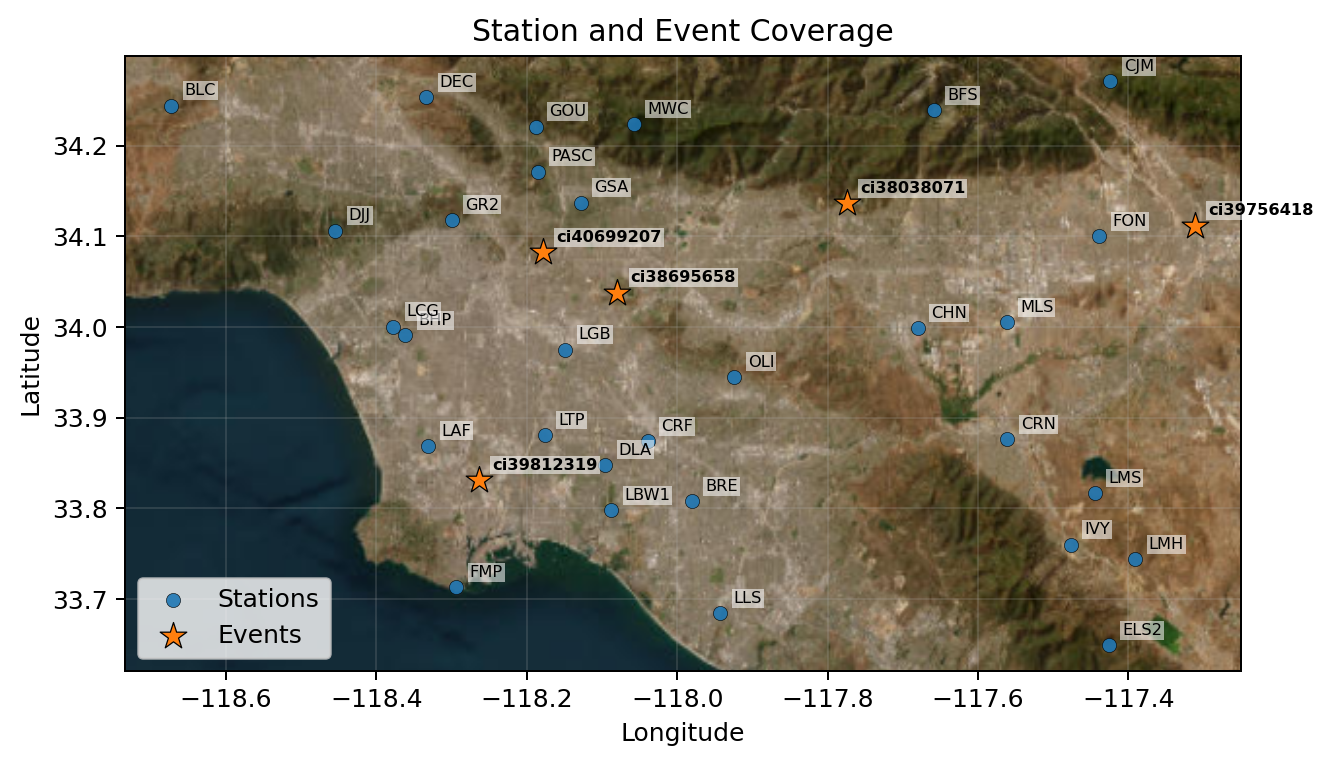

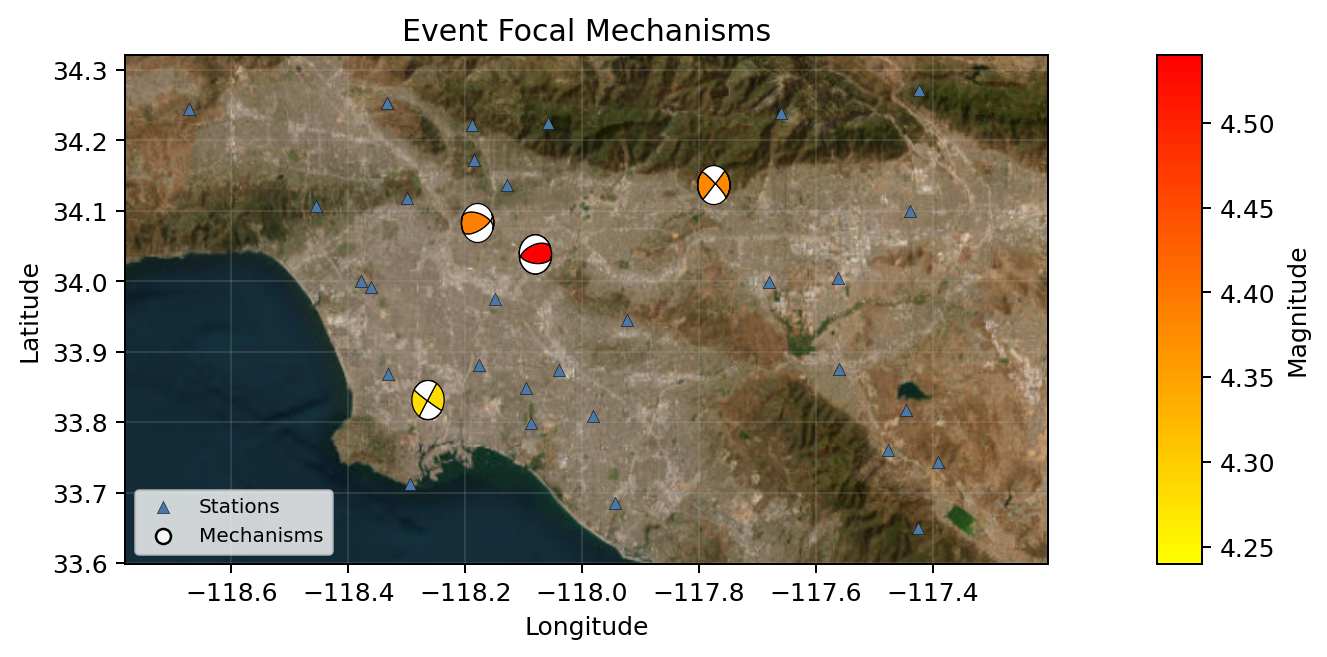

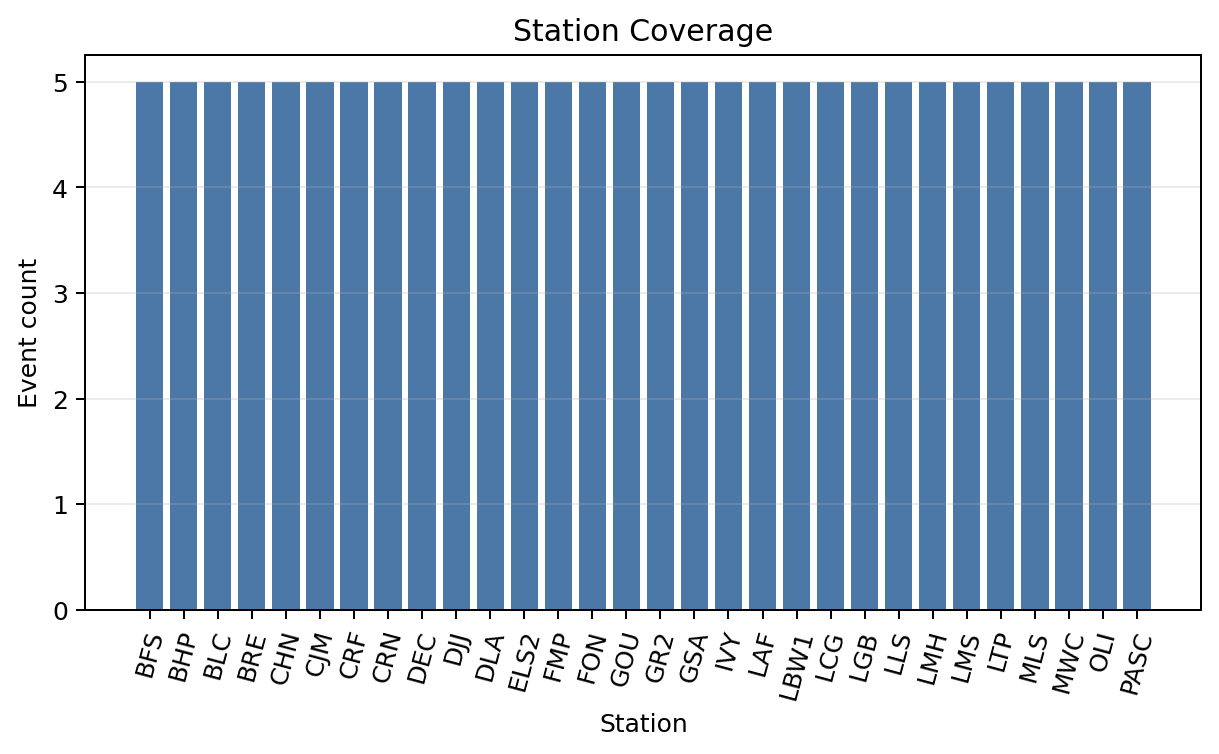

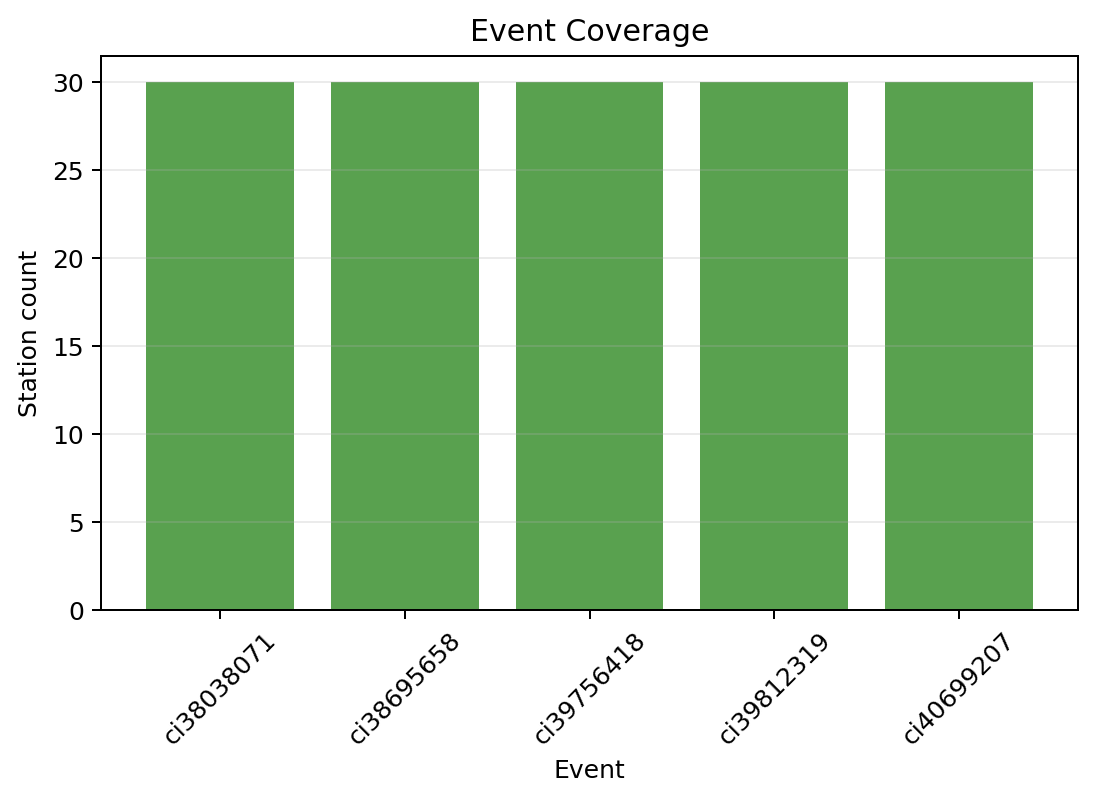

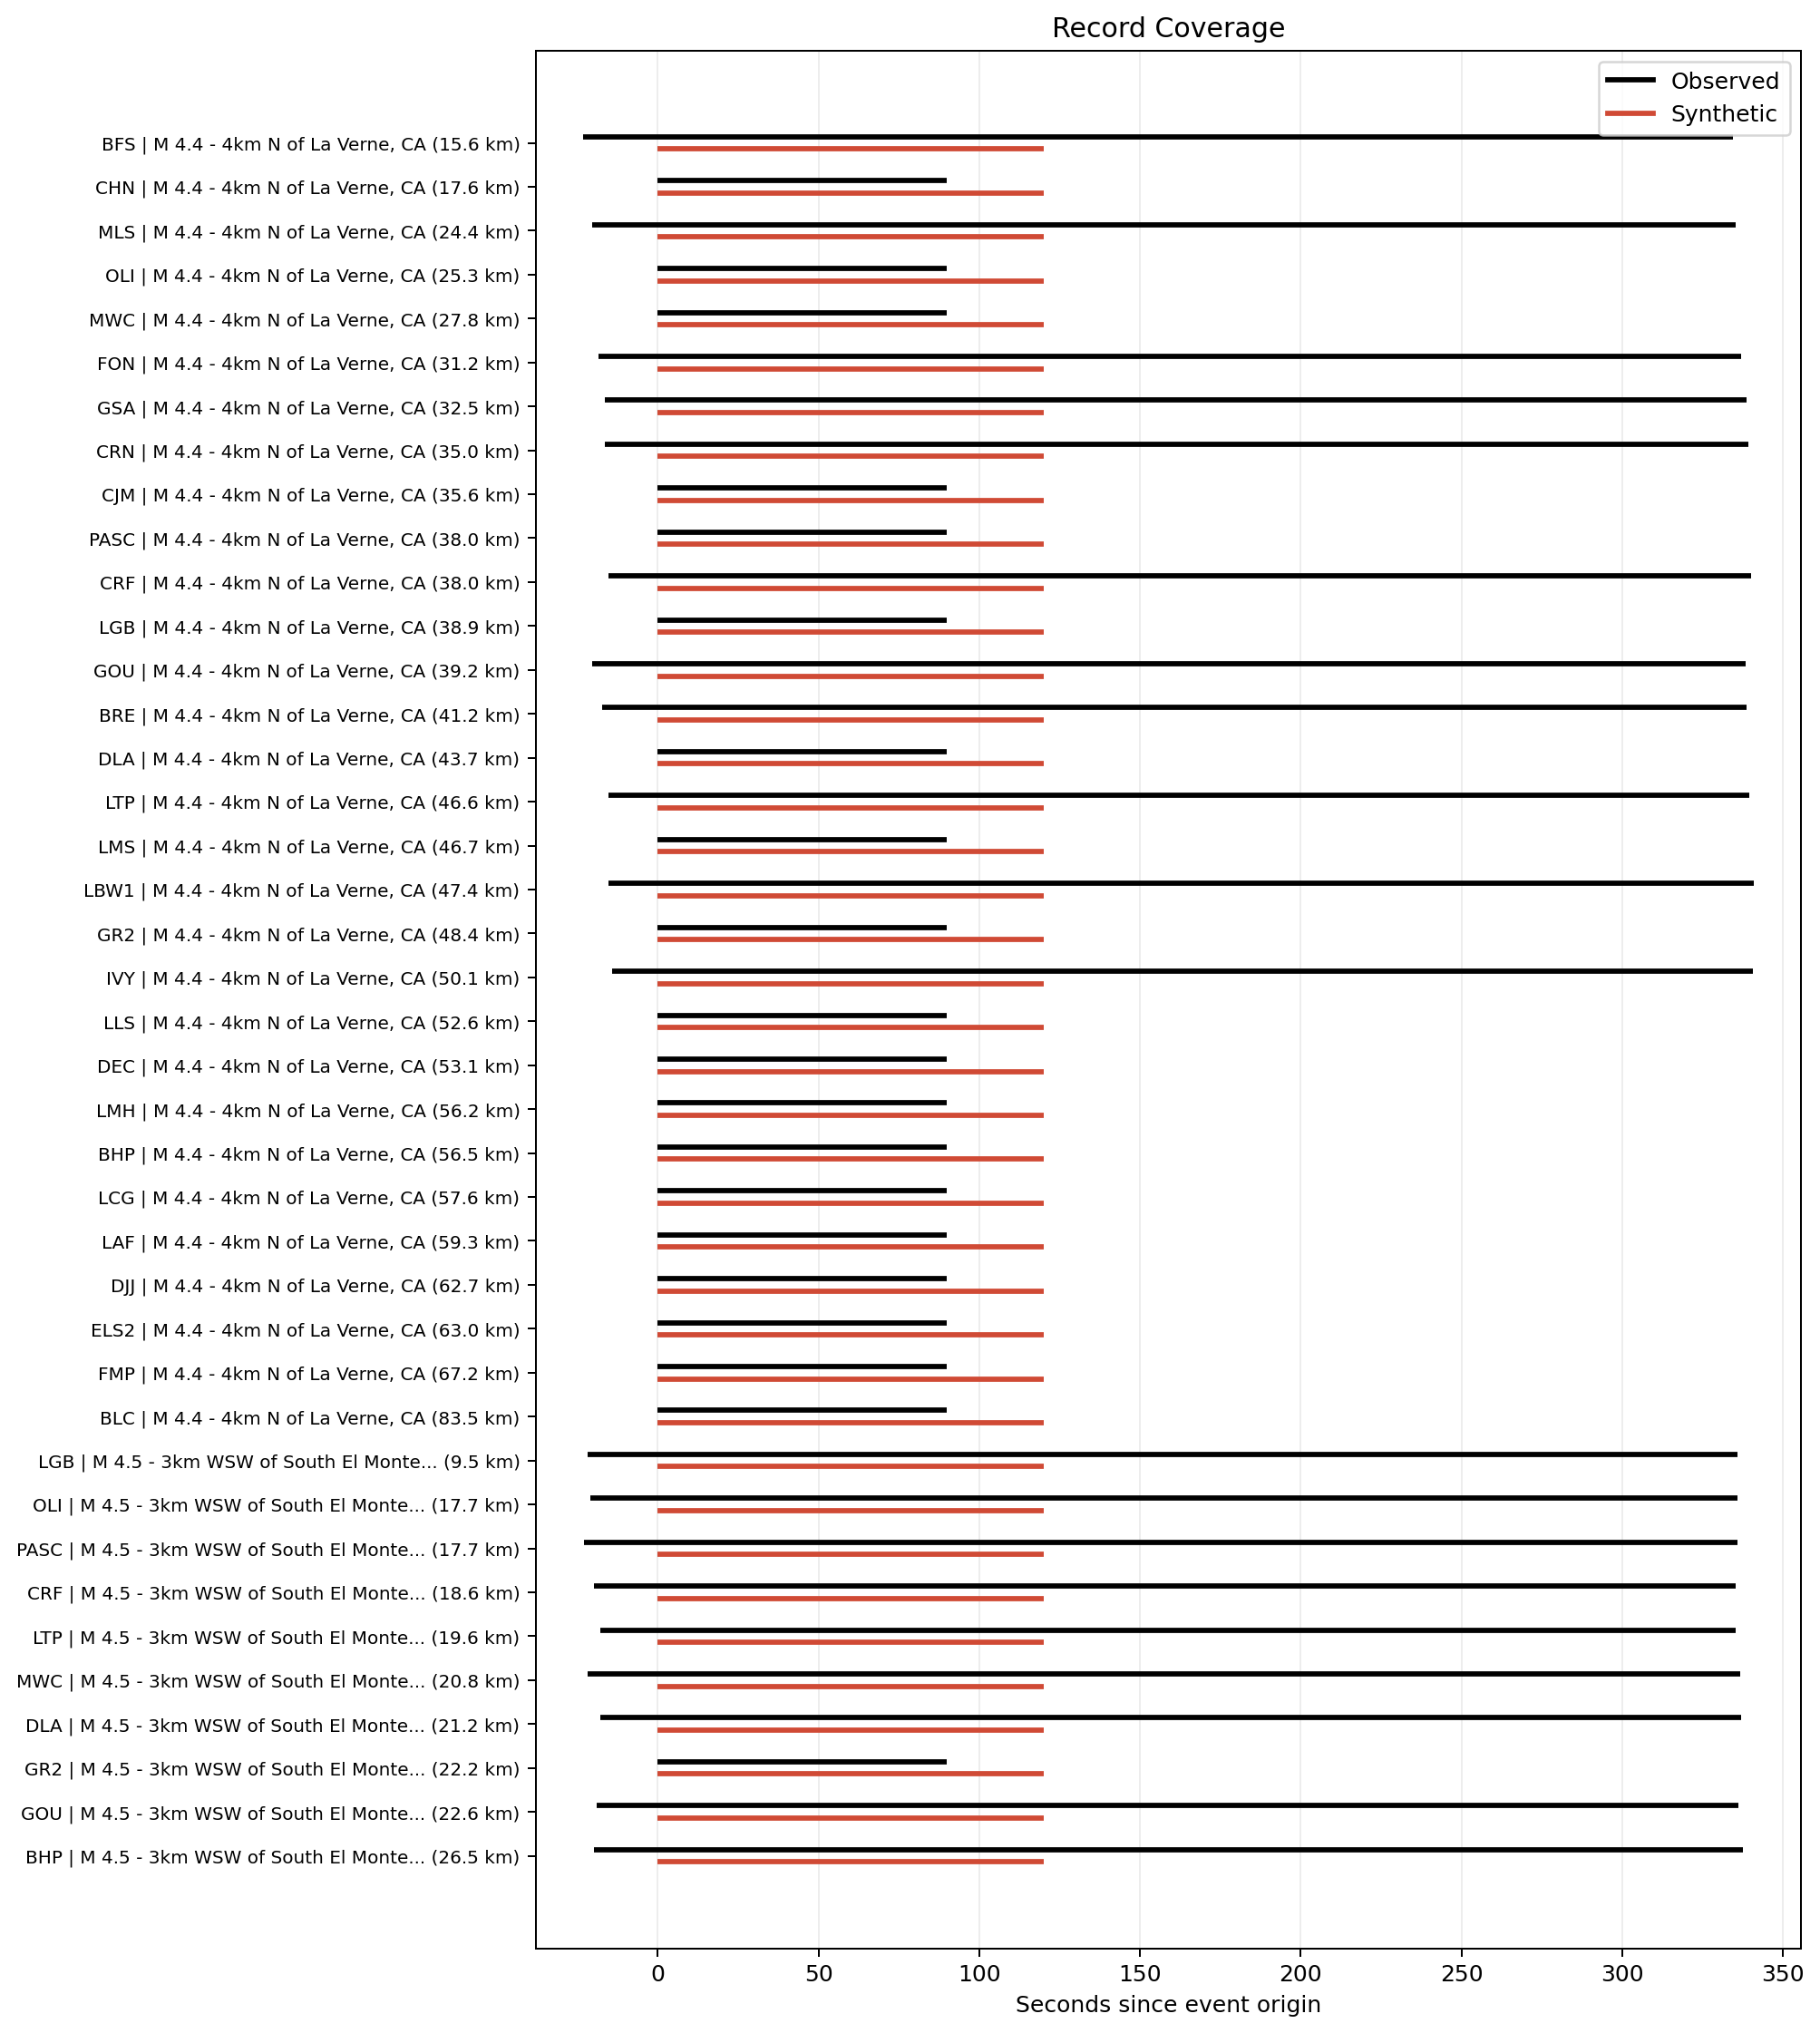

Run time: 20.99 s


In [6]:
# Station-event context map: where the stations and events sit in the study area.
context_fig = plot_station_event_context(
    stations,
    events,
    add_basemap=add_basemap,
    auto_bounds_buffer_fraction=0.045,
    auto_bounds_min_buffer_deg=0.015,
    annotate_stations=True,
    annotate_events=True,
    showfig=True,
    savefig=True,
    close=True,
)

# Event beachball map: focal mechanisms with compressional quadrants colored by magnitude.
event_beachball_fig = plot_station_event_beachball_map(events, stations_df=stations, add_basemap=add_basemap, showfig=True, savefig=True, close=True)

# Station coverage figure: how many events are available at each station.
station_coverage_fig = plot_station_coverage(event_stations, showfig=True, savefig=True, close=True)

# Event coverage figure: how many stations are available for each event.
event_coverage_fig = plot_event_coverage(event_stations, showfig=True, savefig=True, close=True)

# Record coverage figure: observed and synthetic record windows for each event-station pair.
record_coverage_fig = plot_record_coverage(record_coverage, showfig=True, savefig=True, close=True)